In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

import confidence_intervals

In [2]:
indig_data = pd.read_stata('data/all08_11_indigenous.dta')
pd.set_option('display.max_columns', None)

In [3]:
aymara_students = indig_data[indig_data['ethnic_student_08'].isin(['Aymara'])]
aymara_students

,mrun,idregion_schools_08,nem_students_11,leng_students_11,mate_students_11,hria_students_11,cien_students_11,ethnic_father_08,ethnic_mother_08,ethnic_student_08,enroll_PSU_11,take_PSU_11
0,432068,15,478.0,375.0,308.0,328.0,0.0,NaN,Aymara,Aymara,1.0,1.0
1,15695681,15,NaN,NaN,NaN,NaN,NaN,Aymara,Aymara,Aymara,0.0,0.0
3,3782420,15,599.0,552.0,684.0,0.0,545.0,Aymara,Aymara,Aymara,1.0,1.0
4,6986433,15,496.0,508.0,543.0,0.0,495.0,NaN,Aymara,Aymara,1.0,1.0
5,3780037,15,538.0,508.0,505.0,465.0,442.0,Aymara,Aymara,Aymara,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14348,19897775,11,476.0,477.0,432.0,532.0,0.0,NaN,Aymara,Aymara,1.0,1.0
14632,7705428,12,539.0,403.0,447.0,0.0,391.0,NaN,Aymara,Aymara,1.0,1.0
14675,4626108,12,558.0,602.0,552.0,542.0,0.0,Aymara,No indigenous ethnicity,Aymara,1.0,1.0
14743,17253603,12,579.0,514.0,573.0,0.0,554.0,NaN,Aymara,Aymara,1.0,1.0


In [4]:
aymara_took_PSU = aymara_students[~aymara_students['mate_students_11'].isna()]
aymara_took_PSU = aymara_took_PSU[aymara_took_PSU['mate_students_11'] != 0]
aymara_took_PSU

,mrun,idregion_schools_08,nem_students_11,leng_students_11,mate_students_11,hria_students_11,cien_students_11,ethnic_father_08,ethnic_mother_08,ethnic_student_08,enroll_PSU_11,take_PSU_11
0,432068,15,478.0,375.0,308.0,328.0,0.0,NaN,Aymara,Aymara,1.0,1.0
3,3782420,15,599.0,552.0,684.0,0.0,545.0,Aymara,Aymara,Aymara,1.0,1.0
4,6986433,15,496.0,508.0,543.0,0.0,495.0,NaN,Aymara,Aymara,1.0,1.0
5,3780037,15,538.0,508.0,505.0,465.0,442.0,Aymara,Aymara,Aymara,1.0,1.0
6,432069,15,641.0,580.0,580.0,596.0,0.0,Aymara,NaN,Aymara,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14348,19897775,11,476.0,477.0,432.0,532.0,0.0,NaN,Aymara,Aymara,1.0,1.0
14632,7705428,12,539.0,403.0,447.0,0.0,391.0,NaN,Aymara,Aymara,1.0,1.0
14675,4626108,12,558.0,602.0,552.0,542.0,0.0,Aymara,No indigenous ethnicity,Aymara,1.0,1.0
14743,17253603,12,579.0,514.0,573.0,0.0,554.0,NaN,Aymara,Aymara,1.0,1.0


In [5]:
aymara_scores = np.array(aymara_took_PSU['mate_students_11'])
aymara_scores = np.append(aymara_scores, np.ones(1136 - 847) * np.nan)

In [6]:
aymara_scores

array([308., 684., 543., ...,  nan,  nan,  nan], shape=(1136,))

In [14]:
sd = np.std(aymara_scores[~np.isnan(aymara_scores)])
sigma_max = 1.5 * sd
print("Finite variance interval: {}".format(confidence_intervals.adaptive_CI_finite_var(aymara_scores, 0.05, 350)))
print("Sub-Gaussian interval: {}".format(confidence_intervals.adaptive_CI_subG(aymara_scores, 0.05, 700 * 0.62)))
print("Adaptive symmetric interval: {}".format(confidence_intervals.adaptive_CI_sym(aymara_scores, 0.05)))
print("Adaptive bounded interval: {}".format(confidence_intervals.adaptive_CI_bounded(aymara_scores, 0.05, 150, 850)))

Finite variance interval: {'left': 178.13907227692732, 'right': 826.8172441339345}
Sub-Gaussian interval: {'left': 41.653243876123895, 'right': 963.303072534738}
Adaptive symmetric interval: {'left': 447.0, 'right': 567.0}
Adaptive bounded interval: {'left': 337.75082183381073, 'right': 644.7797981395931}


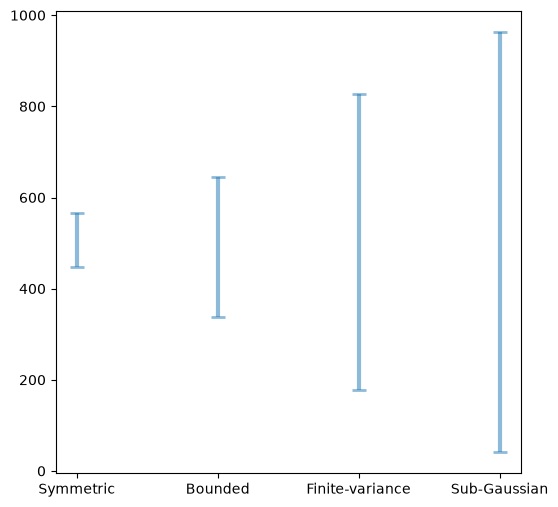

In [8]:
methods = ['Symmetric', 'Bounded', 'Finite-variance', 'Sub-Gaussian']
lowers = [confidence_intervals.adaptive_CI_sym(aymara_scores, 0.05)['left'],
          confidence_intervals.adaptive_CI_bounded(aymara_scores, 0.05, 150, 850)['left'],
          confidence_intervals.adaptive_CI_finite_var(aymara_scores, 0.05, 350)['left'],
          confidence_intervals.adaptive_CI_subG(aymara_scores, 0.05, 700 * 0.62)['left']]
uppers = [confidence_intervals.adaptive_CI_sym(aymara_scores, 0.05)['right'],
          confidence_intervals.adaptive_CI_bounded(aymara_scores, 0.05, 150, 850)['right'],
          confidence_intervals.adaptive_CI_finite_var(aymara_scores, 0.05, 350)['right'],
          confidence_intervals.adaptive_CI_subG(aymara_scores, 0.05, 700 * 0.62)['right']] 

plt.figure(figsize=(6,6))
centers = (np.asarray(lowers) + np.asarray(uppers)) / 2
half_lengths = (np.asarray(uppers) - np.asarray(lowers)) / 2

plt.errorbar(
    methods,
    centers,
    yerr=half_lengths,
    fmt='none',
    capsize=5,
    linewidth=3,
    capthick=2,
    alpha=0.5
)

plt.savefig("Aymara.pdf")